
# Retina‑SEM — SLED Debug Notebook (step‑3)

Use this notebook to **prototype and validate** Structural Entropy Minimization on a few samples before wiring it into the batch script.

**What you can do here:**
- Load a preprocessed RGB fundus image and its **superpixel map** (SLIC labels).
- Build the **superpixel graph** (neighbors + weights) from your stage‑2 outputs.
- Run **SLED (merge → refine)** with detailed logs to confirm the entropy decreases.
- Do **region bisection** (maximize between‑class variance) → vessel vs background.
- Visualize **overlays & boundaries**, save outputs in `outputs_seg/{split}/...`.
- (Optional) Evaluate **Dice / PR‑AUC / clDice** if GT masks are available.


In [1]:
# =====================
# Configuration (for your folder structure)
# =====================
from pathlib import Path
import os

SPLIT = "test"       # "train" | "val" | "test"
SAMPLE_ID = "1_A"   # change this to match your image name (without .png)

# --- Preprocessed image (CLAHE + FOV applied) ---
IMG_RGB_PATH   = Path(f"../preprocessed/{SPLIT}/images/{SAMPLE_ID}.png")

# --- Superpixel label map & graph (from stage 2) ---
SPMAP_NPY_PATH = Path(f"../outputs_seg/{SPLIT}/debug_boundaries/{SAMPLE_ID}.png")
GRAPH_NPZ_PATH = Path(f"../outputs_seg/{SPLIT}/debug_boundaries/{SAMPLE_ID}.png")

# --- Ground truth (optional for metrics) ---
GT_MASK_PATH   = Path(f"../dataset/{SPLIT}/Ground truth/{SAMPLE_ID}.png")

# --- Output dirs (already exist) ---
OUT_ROOT = Path("outputs_seg")/SPLIT
(OUT_ROOT/"debug_boundaries").mkdir(parents=True, exist_ok=True)
(OUT_ROOT/"masks").mkdir(exist_ok=True)
(OUT_ROOT/"overlays").mkdir(exist_ok=True)
(OUT_ROOT/"seed_vis").mkdir(exist_ok=True)

print("✅ Configured for preprocessed images + stage-2 outputs")


✅ Configured for preprocessed images + stage-2 outputs


In [2]:

# =====================
# Imports & utilities
# =====================
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

def imread_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show(title, img, size=6):
    plt.figure(figsize=(size, size))
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title); plt.axis('off'); plt.show()

def overlay_mask(rgb, mask, alpha=0.45):
    rgb = rgb.copy()
    mask3 = np.dstack([mask*255]*3).astype(np.uint8)
    color = np.zeros_like(rgb); color[...,1] = 255  # green overlay
    colored = np.where(mask3>0, color, 0)
    return cv2.addWeighted(rgb, 1.0, colored, alpha, 0.0)

def draw_sp_boundaries(rgb, sp_id_map, color=(255, 100, 0)):
    # Draw boundaries by finding label changes
    h, w = sp_id_map.shape
    b = np.zeros_like(sp_id_map, dtype=np.uint8)
    b[:-1,:] |= (sp_id_map[:-1,:] != sp_id_map[1: ,:])
    b[: ,:-1] |= (sp_id_map[: ,:-1] != sp_id_map[: ,1: ])
    out = rgb.copy()
    out[b>0] = color
    return out

print("Loaded utilities.")


Loaded utilities.


In [7]:
# =====================
# Detect project root (defines ROOT)
# =====================
from pathlib import Path

def find_project_root(start: Path = Path.cwd(), marker: str = "preprocessed") -> Path:
    cur = start
    for _ in range(10):  # walk up max 10 levels
        if (cur / marker).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(f"Couldn't find '{marker}' starting from {start}")

ROOT = find_project_root()
print("✅ Project root:", ROOT)


✅ Project root: d:\Retina SEM Latest\Retina_SEM


sp_id_map dtype: int32 min/max: 3 230
unique labels (sample): [ 3  4  5  6  7  8  9 10 11 12] ... count = 228


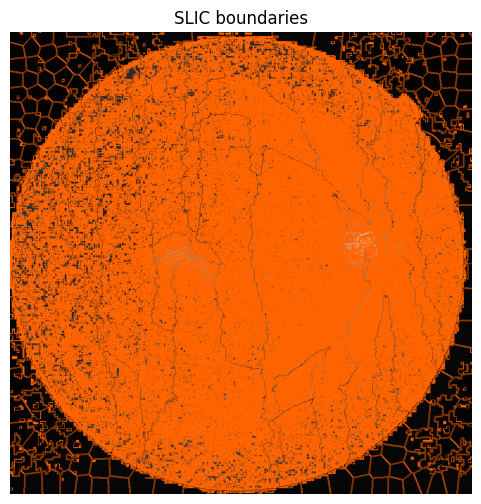

In [8]:
SPLIT = "test"
SAMPLE_ID = "1_A"

IMG_RGB_PATH   = ROOT / "preprocessed" / SPLIT / "images" / f"{SAMPLE_ID}.png"
SPMAP_PNG_PATH = ROOT / "outputs_seg" / SPLIT / "debug_boundaries" / f"{SAMPLE_ID}.png"
GT_MASK_PATH   = ROOT / "dataset" / SPLIT / "Ground truth" / f"{SAMPLE_ID}.png"

import cv2, numpy as np

# RGB (preprocessed)
rgb = imread_rgb(IMG_RGB_PATH)

# Superpixel label map (PNG)
sp_id_map = cv2.imread(str(SPMAP_PNG_PATH), cv2.IMREAD_UNCHANGED)
if sp_id_map is None:
    raise FileNotFoundError(f"Missing SP map: {SPMAP_PNG_PATH}")

if sp_id_map.ndim == 3:
    sp_id_map = cv2.cvtColor(sp_id_map, cv2.COLOR_BGR2GRAY)

sp_id_map = sp_id_map.astype(np.int32)

print("sp_id_map dtype:", sp_id_map.dtype, "min/max:", sp_id_map.min(), sp_id_map.max())
print("unique labels (sample):", np.unique(sp_id_map)[:10], "... count =", len(np.unique(sp_id_map)))
show("SLIC boundaries", draw_sp_boundaries(rgb, sp_id_map))


In [25]:
# =====================
# Build Region Adjacency Graph (RAG) from superpixel PNG + preprocessed RGB
# =====================
import numpy as np
import cv2
from collections import defaultdict
import json

# extra cue: Frangi vesselness (fast settings; tune as needed)
from skimage.filters import frangi
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
ves  = frangi(
    gray,
    scale_range=(1, 3),
    scale_step=1,
    alpha=0.5,   # corresponds to old beta1
    beta=0.5,    # corresponds roughly to old beta2 scaling
    gamma=15.0   # controls noise suppression
)


# Inputs required:
#  - rgb: preprocessed fundus (HxWx3)
#  - sp_id_map: superpixel label map (HxW int32)

H, W = sp_id_map.shape
N = int(sp_id_map.max()) + 1

# 1) Per-superpixel features
rgb_f = rgb.astype(np.float32) / 255.0
green = rgb_f[..., 1]

means_rgb = np.zeros((N, 3), np.float32)
means_g   = np.zeros(N, np.float32)
centroids = np.zeros((N, 2), np.float32)
counts    = np.zeros(N, np.int32)

ys, xs = np.indices((H, W))
for i in range(N):
    mask = (sp_id_map == i)
    cnt = int(mask.sum())
    counts[i] = cnt
    if cnt == 0:
        continue
    means_rgb[i] = rgb_f[mask].mean(axis=0)
    means_g[i]   = green[mask].mean()
    centroids[i] = (ys[mask].mean(), xs[mask].mean())

# 2) Find touching neighbors (RAG)
adj = defaultdict(set)
# vertical borders
diff_v = sp_id_map[1:, :] != sp_id_map[:-1, :]
yv, xv = np.where(diff_v)
for y, x in zip(yv, xv):
    a = sp_id_map[y, x]
    b = sp_id_map[y + 1, x]
    if a != b:
        adj[a].add(b)
        adj[b].add(a)
# horizontal borders
diff_h = sp_id_map[:, 1:] != sp_id_map[:, :-1]
yh, xh = np.where(diff_h)
for y, x in zip(yh, xh):
    a = sp_id_map[y, x]
    b = sp_id_map[y, x + 1]
    if a != b:
        adj[a].add(b)
        adj[b].add(a)

# 3) Convert adjacency to neighbors + weights using richer features
#    feature = [meanG, stdG, meanVesselness, p95Vesselness, cy/H, cx/W]
feat = np.zeros((N, 6), np.float32)
for i in range(N):
    m = (sp_id_map == i)
    if not np.any(m):
        continue
    g_vals = gray[m]
    v_vals = ves[m]
    cy, cx = np.mean(np.where(m), axis=1)  # (row, col)
    feat[i, 0] = g_vals.mean()
    feat[i, 1] = g_vals.std()
    feat[i, 2] = v_vals.mean()
    feat[i, 3] = np.percentile(v_vals, 95)
    feat[i, 4] = cy / H
    feat[i, 5] = cx / W

# self-tuned Gaussian weights per node (Zelnik-Manor)
neighbors, weights = [], []
for i in range(N):
    nbrs = sorted(adj[i]) if i in adj else []
    if not nbrs:
        neighbors.append([]); weights.append([]); continue
    # distances in feature space
    d = [float(np.linalg.norm(feat[i] - feat[j])) for j in nbrs]
    nz = [x for x in d if x > 1e-8]
    sigma = (np.median(nz) if nz else (np.mean(d) + 1e-6)) + 1e-6
    wij = [float(np.exp(-(x * x) / (sigma * sigma))) for x in d]
    neighbors.append(nbrs)
    weights.append(wij)

# (optional) light kNN augmentation on centroids to avoid isolated fragments
# set K_AUG = 0 to disable
K_AUG = 3
if K_AUG > 0:
    from sklearn.neighbors import NearestNeighbors
    cent = feat[:, 4:6]  # (cy/H, cx/W)
    K = min(K_AUG + 1, N)
    nbr = NearestNeighbors(n_neighbors=K).fit(cent)
    dist, idx = nbr.kneighbors(cent)
    for i in range(N):
        for j_idx, d in zip(idx[i, 1:], dist[i, 1:]):  # skip self
            j = int(j_idx)
            if j not in adj[i]:
                # connect with a weak geometric edge (Gaussian on distance)
                sigma_g = 0.05
                w = float(np.exp(-(d * d) / (sigma_g * sigma_g)))
                neighbors[i].append(j); weights[i].append(w)
                neighbors[j].append(i); weights[j].append(w)

# ensure symmetry and convert to pure python types
from collections import defaultdict
acc = defaultdict(dict)
for i, (nbrs, wts) in enumerate(zip(neighbors, weights)):
    for j, w in zip(nbrs, wts):
        w = float(w)
        if j in acc[i]:
            acc[i][j] = max(acc[i][j], w)
        else:
            acc[i][j] = w
        if i in acc[j]:
            acc[j][i] = max(acc[j][i], w)
        else:
            acc[j][i] = w

neighbors_py, weights_py = [], []
for i in range(N):
    if i in acc:
        js = sorted(acc[i].keys())
        ws = [float(acc[i][j]) for j in js]
    else:
        js, ws = [], []
    neighbors_py.append([int(x) for x in js])
    weights_py.append(ws)


# 4) Save so SLED can use it
# --- sanitize to pure Python types (no numpy scalars) ---
def to_py_nested(lst):
    out = []
    for row in lst:
        # row might be list/tuple/np.ndarray
        row_iter = row.tolist() if hasattr(row, "tolist") else row
        out.append([int(x) if isinstance(x, (np.integer,)) else
                    float(x) if isinstance(x, (np.floating,)) else
                    int(x) if isinstance(x, bool) else  # just in case
                    int(x) if isinstance(x, (int,)) else
                    float(x) if isinstance(x, (float,)) else
                    x
                   for x in row_iter])
    return out

neighbors_py = to_py_nested(neighbors)
weights_py   = to_py_nested(weights)

# save to JSON
out_dbg = ROOT / "outputs_seg" / SPLIT / "debug_boundaries"
out_dbg.mkdir(parents=True, exist_ok=True)
graph_json_path = out_dbg / f"{SAMPLE_ID}_graph.json"

import json
with open(graph_json_path, "w", encoding="utf-8") as f:
    json.dump({"neighbors": neighbors_py, "weights": weights_py}, f, separators=(",", ":"))

print("Graph saved:", graph_json_path)



C:\Users\sarve\AppData\Local\Temp\ipykernel_3232\1235464685.py:12: UserWarning: Use keyword parameter `sigmas` instead of `scale_range` and `scale_range` which will be removed in version 0.17.
  ves  = frangi(


Graph saved: d:\Retina SEM Latest\Retina_SEM\outputs_seg\test\debug_boundaries\1_A_graph.json


In [26]:

# =====================
# Graph structure for SLED
# =====================
from dataclasses import dataclass

@dataclass
class Graph:
    N: int
    neighbors: list
    weights: list

def degree_vec(g: Graph) -> np.ndarray:
    return np.array([np.sum(g.weights[i]) for i in range(g.N)], dtype=np.float64)

g = Graph(N=int(sp_id_map.max()+1), neighbors=list(neighbors), weights=list(weights))
deg = degree_vec(g)
print("Graph created. Sum degrees =", float(np.sum(deg)))


Graph created. Sum degrees = 4282.970874675481


In [27]:

# =====================
# SLED core (structural entropy + merge/refine)
# =====================
import numpy as np

def vol_of_module(deg, mask):
    return float(np.sum(deg[mask]))

def cut_of_module(g: Graph, module_mask: np.ndarray) -> float:
    cut = 0.0
    inside = module_mask
    outside = ~inside
    idx = np.where(inside)[0]
    for i in idx:
        for j, w in zip(g.neighbors[i], g.weights[i]):
            if outside[int(j)]:
                cut += float(w)
    return float(cut)

def structural_entropy(g: Graph, partition: list[np.ndarray], deg: np.ndarray) -> float:
    volG = float(np.sum(deg))
    H = 0.0
    for mask in partition:
        volX = vol_of_module(deg, mask)
        if volX <= 0: 
            continue
        di = deg[mask]
        # term1
        H -= float(np.sum((di/volG) * np.log2(np.maximum(di/volX, 1e-12))))
        # term2
        cutX = cut_of_module(g, mask)
        H -= (cutX/volG) * np.log2(np.maximum(volX/volG, 1e-12))
    return H

def initial_partition(N: int):
    # each node -> its own module
    return [np.eye(1, N, k, dtype=bool).ravel() for k in range(N)]

def delta_H_merge(g: Graph, deg: np.ndarray, maskX: np.ndarray, maskY: np.ndarray, volG: float) -> float:
    def _vol(m): return float(np.sum(deg[m]))
    def _cut(m): return cut_of_module(g, m)
    vX, vY = _vol(maskX), _vol(maskY)
    cX, cY = _cut(maskX), _cut(maskY)
    XY = maskX | maskY
    vXY, cXY = _vol(XY), _cut(XY)
    term = (
        (vX - cX) * np.log2(max(vX, 1e-12)) +
        (vY - cY) * np.log2(max(vY, 1e-12)) -
        (vXY - cXY) * np.log2(max(vXY,1e-12)) +
        (cX + cY - cXY) * np.log2(max(volG,1e-12))
    ) / volG
    return float(term)

def merging_stage(g: Graph, partition: list[np.ndarray], deg: np.ndarray, max_merges_per_round=None):
    volG = float(np.sum(deg))
    history = []
    while True:
        best_gain, best_pair = 0.0, None
        M = len(partition)
        # optionally limit the scan for speed on big N
        merges_done = 0
        for i in range(M):
            for j in range(i+1, M):
                dH = delta_H_merge(g, deg, partition[i], partition[j], volG)
                if dH > best_gain:
                    best_gain, best_pair = dH, (i, j)
        if best_pair is None or best_gain <= 0:
            break
        i, j = best_pair
        merged = partition[i] | partition[j]
        partition[i] = merged
        del partition[j]
        merges_done += 1
        history.append(("merge", best_gain, len(partition)))
        if max_merges_per_round and merges_done >= max_merges_per_round:
            break
    return partition, history

def delta_H_refine_remove(g: Graph, deg: np.ndarray, maskX: np.ndarray, idx: int, volG: float) -> float:
    # SE decrease by removing node idx from X (Eq. 4)
    vX = vol_of_module(deg, maskX); cX = cut_of_module(g, maskX)
    if not maskX[idx]:
        return 0.0
    m2 = maskX.copy(); m2[idx] = False
    vX2 = vol_of_module(deg, m2); cX2 = cut_of_module(g, m2)
    t1 = (vX - cX)/volG * np.log2(max(vX/volG, 1e-12))
    t2 = (vX2 - cX2)/volG * np.log2(max(vX2/volG, 1e-12))
    return float(t1 - t2)

def delta_H_refine_insert(g: Graph, deg: np.ndarray, maskY: np.ndarray, idx: int, volG: float) -> float:
    # SE increase by inserting node idx into Y (Eq. 5)
    vY = vol_of_module(deg, maskY); cY = cut_of_module(g, maskY)
    m2 = maskY.copy(); m2[idx] = True
    vY2 = vol_of_module(deg, m2); cY2 = cut_of_module(g, m2)
    t1 = -(vY/volG) * np.log2(max(vY/volG, 1e-12))
    t2 =  (vY2 - cY2)/volG * np.log2(max(vY2/volG, 1e-12))
    return float(t1 + t2)

def refinement_stage(g: Graph, partition: list[np.ndarray], deg: np.ndarray, max_passes=2):
    volG = float(np.sum(deg))
    history = []
    for p in range(max_passes):
        moved = 0
        # node -> current module
        node2mod = np.full(g.N, -1, dtype=int)
        for k, m in enumerate(partition):
            node2mod[m] = k
        for i in range(g.N):
            Xi = node2mod[i]
            d_rem = delta_H_refine_remove(g, deg, partition[Xi], i, volG)
            best_gain, bestY = 0.0, None
            for Y in range(len(partition)):
                if Y == Xi: 
                    continue
                d_ins = delta_H_refine_insert(g, deg, partition[Y], i, volG)
                gain = d_rem - d_ins
                if gain > best_gain:
                    best_gain, bestY = gain, Y
            if bestY is not None and best_gain > 0:
                partition[Xi][i] = False
                partition[bestY][i] = True
                moved += 1
        # drop empty modules
        partition = [m for m in partition if np.any(m)]
        history.append(("refine_pass", p, moved, len(partition)))
        if moved == 0:
            break
    return partition, history

def sled_partition(g: Graph, deg: np.ndarray, log_every=True):
    P = initial_partition(g.N)
    H0 = structural_entropy(g, P, deg)
    if log_every: print(f"[INIT] modules={len(P)}  SE={H0:.6f}")
    P, hist_m = merging_stage(g, P, deg)
    H1 = structural_entropy(g, P, deg)
    if log_every: print(f"[MERGE] modules={len(P)}  SE={H1:.6f}  (Δ={H1-H0:.6f})")
    P, hist_r = refinement_stage(g, P, deg, max_passes=3)
    H2 = structural_entropy(g, P, deg)
    if log_every: print(f"[REFINE] modules={len(P)}  SE={H2:.6f}  (Δ={H2-H1:.6f})")
    return P, dict(H0=H0, H1=H1, H2=H2, merge_hist=hist_m, refine_hist=hist_r)
print("SLED core loaded.")


SLED core loaded.


[INIT] modules=231  SE=7.707355
[MERGE] modules=9  SE=5.714587  (Δ=-1.992768)
[REFINE] modules=9  SE=5.714587  (Δ=0.000000)
History: [('merge', 0.008017009218105907, 230), ('merge', 0.008458081227910497, 229), ('merge', 0.0078060659728415496, 228)] ...  | refine: [('refine_pass', 0, 0, 9)]


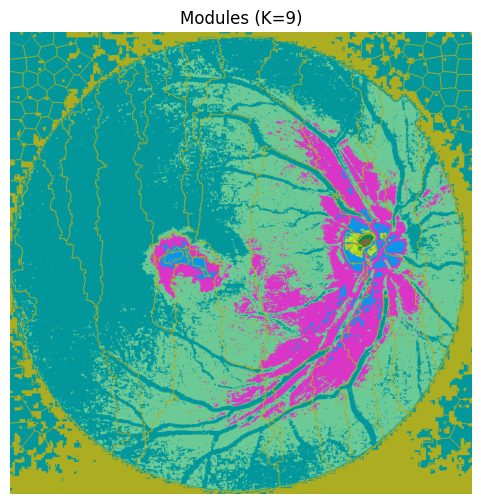

True

In [28]:

# =====================
# Run SLED on this graph
# =====================
P, info = sled_partition(g, deg, log_every=True)
print("History:", info['merge_hist'][:3], "...", " | refine:", info['refine_hist'])

# Randomly color modules for visualization
rng = np.random.default_rng(123)
colors = rng.integers(0, 255, size=(len(P), 3), dtype=np.uint8)
node2color = np.zeros((g.N, 3), dtype=np.uint8)
for k, m in enumerate(P):
    node2color[m] = colors[k]

colored = node2color[sp_id_map]  # HxWx3
show(f"Modules (K={len(P)})", colored, size=6)
cv2.imwrite(str(OUT_ROOT/"seed_vis"/f"{SAMPLE_ID}_modules.png"), cv2.cvtColor(colored, cv2.COLOR_RGB2BGR))


sigma^2_B = 0.008045 | vessel modules = 3/9


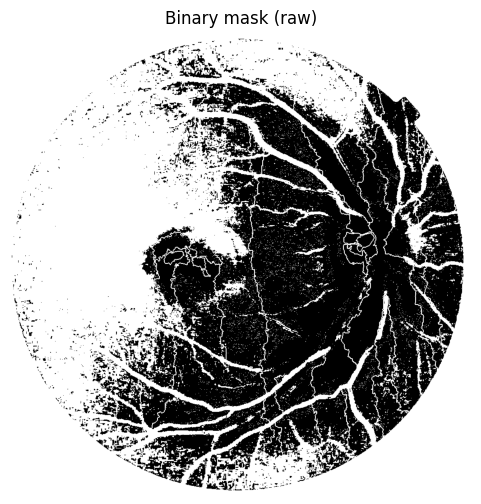

True

In [29]:

# =====================
# Region bisection (vessel vs background)
# =====================
green = rgb[...,1].astype(np.float32) / 255.0

def module_means_sizes(P, sp_id_map, gray):
    means, sizes = [], []
    for mask in P:
        node_ids = np.where(mask)[0]
        pix_mask = np.isin(sp_id_map, node_ids)
        vals = gray[pix_mask]
        means.append(float(vals.mean()) if vals.size else 0.0)
        sizes.append(int(pix_mask.sum()))
    return np.array(means), np.array(sizes, int)

def best_bisection(means, sizes):
    order = np.argsort(means)
    m = means[order]; s = sizes[order]
    M = float(np.sum(s)) if np.sum(s)>0 else 1.0
    cum_s = np.cumsum(s)
    cum_ms = np.cumsum(s*m)
    muT = cum_ms[-1]/M
    best_k, best_val = 0, -1.0
    for k in range(1, len(m)):
        w0 = cum_s[k-1]/M; w1 = 1.0 - w0
        mu0 = (cum_ms[k-1]/cum_s[k-1]) if cum_s[k-1]>0 else 0.0
        mu1 = ((cum_ms[-1]-cum_ms[k-1])/(M-cum_s[k-1])) if (M-cum_s[k-1])>0 else 0.0
        sigma2 = w0*(mu0-muT)**2 + w1*(mu1-muT)**2
        if sigma2 > best_val:
            best_val = sigma2; best_k = k
    vessel_mod_ids = set(np.argsort(means)[:best_k])  # darker class
    return vessel_mod_ids, best_val

means, sizes = module_means_sizes(P, sp_id_map, green)
vessel_ids, sigma2B = best_bisection(means, sizes)
print(f"sigma^2_B = {sigma2B:.6f} | vessel modules = {len(vessel_ids)}/{len(P)}")

# Build binary mask
node_is_vessel = np.zeros(g.N, dtype=bool)
for k, mask in enumerate(P):
    if k in vessel_ids:
        node_is_vessel[np.where(mask)[0]] = True
bin_mask = node_is_vessel[sp_id_map].astype(np.uint8)

show("Binary mask (raw)", bin_mask*255, size=6)
cv2.imwrite(str(OUT_ROOT/"masks"/f"{SAMPLE_ID}_raw.png"), bin_mask*255)


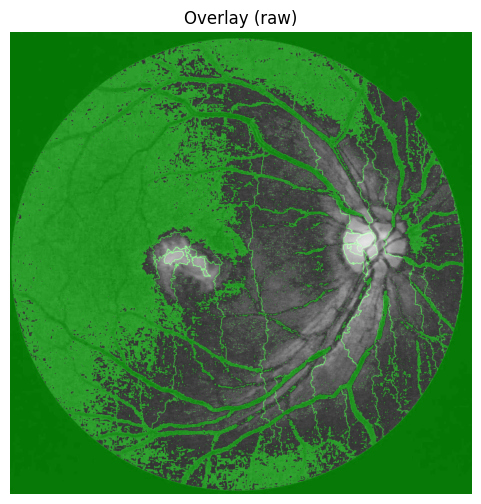

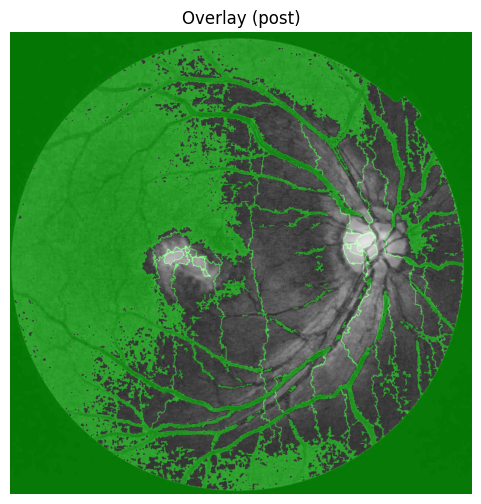

True

In [30]:

# =====================
# Post-processing & overlays
# =====================
# Morph closing & small component removal (tunable)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
post = cv2.morphologyEx(bin_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

# Remove tiny blobs
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(post, connectivity=8)
areas = stats[:, cv2.CC_STAT_AREA]
keep = np.ones(num_labels, dtype=bool)
min_area = 30  # tune for your image scale
keep[areas < min_area] = False
keep[0] = False  # background
post2 = np.isin(labels, np.where(keep)[0]).astype(np.uint8)

ov1 = overlay_mask(rgb, bin_mask, alpha=0.45)
ov2 = overlay_mask(rgb, post2, alpha=0.45)

show("Overlay (raw)", ov1, size=6)
show("Overlay (post)", ov2, size=6)

cv2.imwrite(str(OUT_ROOT/"overlays"/f"{SAMPLE_ID}_raw.png"), cv2.cvtColor(ov1, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUT_ROOT/"overlays"/f"{SAMPLE_ID}_post.png"), cv2.cvtColor(ov2, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUT_ROOT/"masks"/f"{SAMPLE_ID}_post.png"), post2*255)


In [31]:
# =====================
# Align GT to prediction shape + evaluate (Dice, optional clDice)
# =====================
import cv2
import numpy as np

# 1) Load + binarize GT (if not already loaded)
gt = cv2.imread(str(GT_MASK_PATH), cv2.IMREAD_GRAYSCALE)
if gt is None:
    raise FileNotFoundError(f"GT not found: {GT_MASK_PATH}")

# Some GTs are white background / black vessels. Auto-fix if needed:
# Heuristic: if vessels are dark (mean of vessel pixels < mean of background), invert so vessels=1
gt_bin = (gt > 127).astype(np.uint8)
if gt_bin.mean() < 0.3:  # too few positives? try invert heuristic
    gt_bin = (gt <= 127).astype(np.uint8)

# 2) Resize GT to prediction size (use NEAREST for masks)
H, W = bin_mask.shape[:2]
gt_resized = cv2.resize(gt_bin, (W, H), interpolation=cv2.INTER_NEAREST).astype(np.uint8)

# 3) (Optional but recommended) restrict comparison to FOV
# If you have a saved FOV mask, load it; otherwise build a quick ring mask from the preprocessed image
FOV_PATH = ROOT / "preprocessed" / SPLIT / "fov_masks" / f"{SAMPLE_ID}.png"
if FOV_PATH.exists():
    fov = cv2.imread(str(FOV_PATH), cv2.IMREAD_GRAYSCALE)
    fov = cv2.resize(fov, (W, H), interpolation=cv2.INTER_NEAREST)
    fov = (fov > 127).astype(np.uint8)
else:
    # Quick fallback: derive FOV by thresholding a lightness map
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    _, fov = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
    fov = (fov > 0).astype(np.uint8)

# 4) Dice (inside FOV)
def dice(a, b, m=None):
    a = a.astype(bool); b = b.astype(bool)
    if m is not None:
        m = m.astype(bool)
        a = np.logical_and(a, m)
        b = np.logical_and(b, m)
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    return (2 * inter) / (denom + 1e-12)

d_raw  = dice(gt_resized, bin_mask, fov)
d_post = dice(gt_resized, post2,    fov)
print(f"Dice (raw)  : {d_raw:.4f}")
print(f"Dice (post) : {d_post:.4f}")


Dice (raw)  : 0.5683
Dice (post) : 0.5745


In [32]:

# =====================
# (Optional) Metrics if GT available
# =====================
if GT_MASK_PATH.exists():
    gt = cv2.imread(str(GT_MASK_PATH), cv2.IMREAD_GRAYSCALE)
    gt = (gt > 127).astype(np.uint8)
    # Dice coefficient with optional FOV mask
    def dice(a, b, fov=None):
        a = a.astype(bool)
        b = b.astype(bool)
        if fov is not None:
            fov = fov.astype(bool)
            a = np.logical_and(a, fov)
            b = np.logical_and(b, fov)
        inter = np.logical_and(a, b).sum()
        return 2 * inter / (a.sum() + b.sum() + 1e-12)

    d_raw = dice(gt_resized, bin_mask, fov)
    d_post = dice(gt_resized, post2,    fov)

    print(f"Dice raw={d_raw:.4f} | post={d_post:.4f}")
else:
    print("GT not found; skipping metrics.")


Dice raw=0.5683 | post=0.5745
